# 02 – Modeling

**Phase 3:** a simple baseline to beat. **Phase 4:** more features, a log-transformed target, Random Forest vs. LightGBM, cross-validation.

**Key terms**
- **Feature** = an input the model uses (living space, city, balcony …). **Target** = what we predict (`baseRent`).
- **Model** = a formula/algorithm that learns the relationship between features and target from examples.
- **MAE (Mean Absolute Error)** = on average, how many euros is the prediction off? *Lower is better.* If MAE = €100, predictions are on average €100 too high or too low.
- **R²** = share of the differences in rent the model explains (0 = nothing, 1 = everything).

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from lightgbm import LGBMRegressor

import cleaning
from cleaning import TARGET, FEATURES, NUMERIC_FEATURES, BOOLEAN_FEATURES, CATEGORICAL_FEATURES
from train import build_model   # the final model definition, shared with src/train.py

# Chart style: one calm blue for data, orange only to highlight, light grey grid
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 130, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "axes.axisbelow": True,
    "axes.edgecolor": "#8a8983", "axes.labelcolor": GREY,
    "xtick.color": GREY, "ytick.color": GREY,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})

## 1. Load, clean and prepare the data
`prepare_features` selects our 14 features, turns yes/no columns into 1/0 and fills missing text values with `"unknown"`.

In [2]:
df = cleaning.clean_data(cleaning.load_raw("../data/immo_data.csv"))
X = cleaning.prepare_features(df)
y = df[TARGET]
print(f"{len(X):,} apartments, {X.shape[1]} features: {FEATURES}")
X.head()

257,242 apartments, 14 features: ['livingSpace', 'noRooms', 'yearConstructed', 'balcony', 'hasKitchen', 'lift', 'cellar', 'garden', 'newlyConst', 'regio1', 'regio2', 'condition', 'typeOfFlat', 'interiorQual']


,livingSpace,noRooms,yearConstructed,balcony,hasKitchen,lift,cellar,garden,newlyConst,regio1,regio2,condition,typeOfFlat,interiorQual
0,86.00,4.0,1965.0,0,0,0,1,1,0,Nordrhein_Westfalen,Dortmund,well_kept,ground_floor,normal
1,89.00,3.0,1871.0,1,0,0,0,0,0,Rheinland_Pfalz,Rhein_Pfalz_Kreis,refurbished,ground_floor,normal
2,83.80,3.0,2019.0,1,0,1,1,0,1,Sachsen,Dresden,first_time_use,apartment,sophisticated
3,58.15,3.0,1964.0,1,0,0,0,0,0,Sachsen,Mittelsachsen_Kreis,unknown,other,unknown
4,84.97,3.0,1950.0,1,0,0,0,0,0,Bremen,Bremen,refurbished,apartment,unknown


## 2. Train/test split (80/20)
We hide 20% of the apartments from the model (**test set**) and train only on the other 80% (**training set**).
At the end we check the predictions on the hidden 20%. This tells us how well the model works on **apartments it has never seen** – which is exactly the situation in the app.

Without this, a model could simply **memorise** the training data (*overfitting*) and look perfect while being useless for new flats.
`random_state=42` makes the random split the same every time we run the notebook.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {len(X_train):,} rows | Test set: {len(X_test):,} rows")

Training set: 205,793 rows | Test set: 51,449 rows


## 3. Cross-validation and a helper to compare models
One test split could be lucky or unlucky. **5-fold cross-validation (CV)** splits the *training* set into 5 parts, trains on 4 and measures on the 5th – five times, each part once as the "check" part. The average of the 5 scores is more reliable than a single number.

We **choose models by their CV score** and keep the test set as a final, independent check.

In [4]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

def evaluate(name, model, features=FEATURES):
    """Cross-validate on the training set, then fit on all training data and score on the test set."""
    cv_mae = -cross_val_score(model, X_train[features], y_train, cv=cv, scoring="neg_mean_absolute_error")
    model.fit(X_train[features], y_train)
    pred = model.predict(X_test[features])
    results.append({
        "Model": name,
        "CV MAE (€)": cv_mae.mean(),
        "CV MAE std (€)": cv_mae.std(),
        "Test MAE (€)": mean_absolute_error(y_test, pred),
        "Test R²": r2_score(y_test, pred),
    })
    print(f"{name}: CV MAE €{cv_mae.mean():.1f} (± {cv_mae.std():.1f}) | test MAE €{results[-1]['Test MAE (€)']:.1f}")
    return model

## 4. Phase 3 – Baselines
### 4.1 "Dumb" baseline: always predict the median rent
It ignores every feature. Any real model **must** beat this, otherwise it has learned nothing.

In [5]:
evaluate("Median baseline", DummyRegressor(strategy="median"));

Median baseline: CV MAE €303.6 (± 1.8) | test MAE €306.9


### 4.2 Linear Regression with 3 features
**Linear Regression** fits the formula `rent = a + b·livingSpace + c·noRooms + (a fixed amount per Bundesland)` – it finds the numbers a, b, c … that fit the training data best.

A model only understands numbers, so the text column `regio1` is turned into 16 yes/no columns with **one-hot encoding**: `regio1_Bayern = 1` if the flat is in Bayern, else 0, and so on.

A **pipeline** chains the preprocessing and the model into one object, so exactly the same steps run during training and prediction.

In [6]:
baseline_features = ["livingSpace", "noRooms", "regio1"]
linear_simple = make_pipeline(
    ColumnTransformer([
        ("numbers", "passthrough", ["livingSpace", "noRooms"]),
        ("one_hot", OneHotEncoder(handle_unknown="ignore"), ["regio1"]),
    ]),
    LinearRegression(),
)
evaluate("Linear Regression (size, rooms, Bundesland)", linear_simple, baseline_features);

Linear Regression (size, rooms, Bundesland): CV MAE €173.4 (± 1.3) | test MAE €175.2


With just three features the error drops from about €307 to €175 (−43%): size and Bundesland explain a big part of the rent.

## 5. Phase 4 – Better models
### 5.1 Linear Regression with all 14 features
New features: city/district (`regio2`, 419 values), `yearConstructed`, the extras (balcony, kitchen, lift, cellar, garden, new building), `condition`, `typeOfFlat` and `interiorQual`.

**Missing construction years:** Linear Regression can't handle empty values. `SimpleImputer` fills them with the median year **and** adds a yes/no column "year was missing" (`add_indicator=True`), so the model can still learn if missing years behave differently.

In [7]:
linear_preprocessing = ColumnTransformer([
    ("numbers", SimpleImputer(strategy="median", add_indicator=True), NUMERIC_FEATURES),
    ("yes_no", "passthrough", BOOLEAN_FEATURES),
    ("one_hot", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
])
evaluate("Linear Regression (all features)", make_pipeline(linear_preprocessing, LinearRegression()));

Linear Regression (all features): CV MAE €120.4 (± 0.8) | test MAE €121.3


### 5.2 Log-transformed target
In `01_exploration` we saw the rent is right-skewed and that `log(rent)` looks like a bell curve. Also, many effects are **percentages**, not fixed amounts: a balcony adds maybe +3% – that's €15 on a €500 flat but €60 on a €2,000 flat. On the log scale, percentage effects become simple additions, which fits a linear model much better.

`TransformedTargetRegressor` trains on `log(rent)` and converts predictions back to euros with `exp()` automatically. The MAE is still measured in **euros**.

In [8]:
evaluate("Linear Regression (all features, log target)",
         TransformedTargetRegressor(make_pipeline(linear_preprocessing, LinearRegression()),
                                    func=np.log, inverse_func=np.exp));

Linear Regression (all features, log target): CV MAE €112.7 (± 1.1) | test MAE €114.3


### 5.3 Random Forest
A **decision tree** asks yes/no questions ("living space > 80 m²?", "city = München?") and ends in a predicted rent. A single tree overfits easily.
A **Random Forest** trains 100 trees, each on a random sample of the data, and **averages** their predictions → much more stable.

Trees can learn **non-linear effects** (e.g. both very old *Altbau* and brand-new buildings are expensive) and **interactions** (a m² in München is worth more than in Chemnitz) on their own.
Trees don't need one-hot encoding: `OrdinalEncoder` simply numbers the categories (Bayern = 0, Berlin = 1, …).
`min_samples_leaf=3` means every final answer is based on at least 3 apartments, which limits overfitting.

In [9]:
tree_preprocessing = ColumnTransformer([
    ("numbers", SimpleImputer(strategy="median", add_indicator=True), NUMERIC_FEATURES),
    ("yes_no", "passthrough", BOOLEAN_FEATURES),
    ("categories", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CATEGORICAL_FEATURES),
])
random_forest = make_pipeline(
    tree_preprocessing,
    RandomForestRegressor(n_estimators=100, min_samples_leaf=3, n_jobs=-1, random_state=42),
)
evaluate("Random Forest (log target)",
         TransformedTargetRegressor(random_forest, func=np.log, inverse_func=np.exp));

Random Forest (log target): CV MAE €101.8 (± 0.8) | test MAE €100.2


### 5.4 LightGBM (gradient boosting)
**Gradient boosting** also uses many trees, but builds them **one after another**: each new tree focuses on correcting the errors the previous trees still make. **LightGBM** is a fast, popular implementation of this idea and often wins on table data like ours.

Two advantages here:
- It handles **missing values** itself (no imputer needed – it learns the best direction for "year unknown").
- It handles **category columns** like the city directly (no encoding needed).

Settings: 1,000 trees, learning rate 0.05 (how much each tree may correct), up to 63 leaves per tree. We first train it on the plain rent, then on log(rent).

In [10]:
evaluate("LightGBM", LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=63, random_state=42, verbose=-1));
final_model = evaluate("LightGBM (log target)", build_model())

LightGBM: CV MAE €86.3 (± 0.4) | test MAE €86.0


LightGBM (log target): CV MAE €84.6 (± 0.5) | test MAE €84.5


## 6. Results

In [11]:
results_table = pd.DataFrame(results).round({"CV MAE (€)": 1, "CV MAE std (€)": 1, "Test MAE (€)": 1, "Test R²": 3})
results_table.to_csv("../reports/model_results.csv", index=False)
results_table

,Model,CV MAE (€),CV MAE std (€),Test MAE (€),Test R²
0,Median baseline,303.6,1.8,306.9,-0.107
1,"Linear Regression (size, rooms, Bundesland)",173.4,1.3,175.2,0.653
2,Linear Regression (all features),120.4,0.8,121.3,0.819
3,"Linear Regression (all features, log target)",112.7,1.1,114.3,0.724
4,Random Forest (log target),101.8,0.8,100.2,0.854
5,LightGBM,86.3,0.4,86.0,0.898
6,LightGBM (log target),84.6,0.5,84.5,0.896


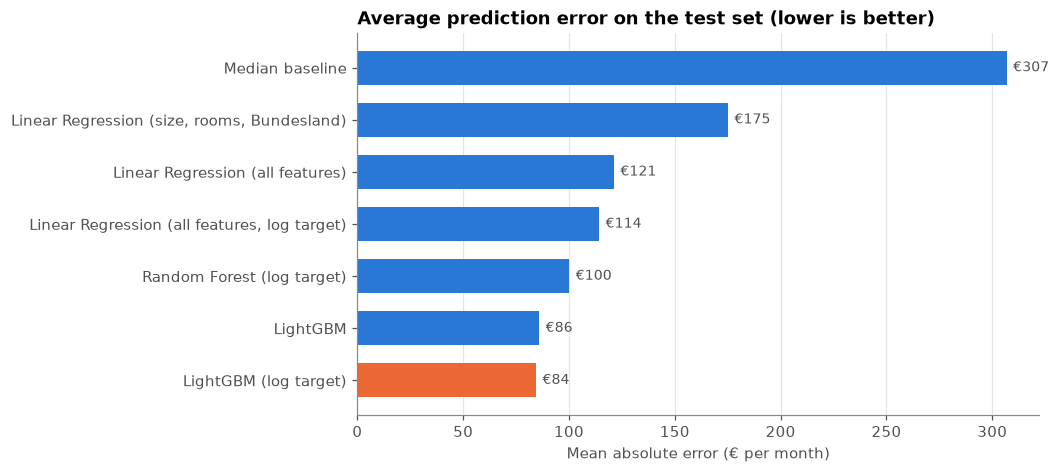

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
table = results_table.iloc[::-1]
colors = [ORANGE if name == "LightGBM (log target)" else BLUE for name in table["Model"]]
ax.barh(table["Model"], table["Test MAE (€)"], color=colors, height=0.65)
for i, value in enumerate(table["Test MAE (€)"]):
    ax.text(value + 3, i, f"€{value:.0f}", va="center", color=GREY, fontsize=9)
ax.set(title="Average prediction error on the test set (lower is better)", xlabel="Mean absolute error (€ per month)")
ax.grid(axis="y", visible=False)
plt.savefig("../images/model_comparison.png")
plt.show()

## 7. A closer look at the best model
MAE in euros is easy to understand, but €80 means something different for a €300 and a €3,000 flat. So we also look at the **percentage error**.

In [13]:
pred = final_model.predict(X_test)
abs_pct_error = np.abs(pred - y_test) / y_test
print(f"Test MAE:                     €{mean_absolute_error(y_test, pred):.1f}")
print(f"Median absolute % error:      {np.median(abs_pct_error):.1%}")
print(f"Predictions within ±10%:      {(abs_pct_error <= 0.10).mean():.1%}")
print(f"Predictions within ±20%:      {(abs_pct_error <= 0.20).mean():.1%}")

Test MAE:                     €84.5
Median absolute % error:      9.3%
Predictions within ±10%:      53.2%
Predictions within ±20%:      81.5%


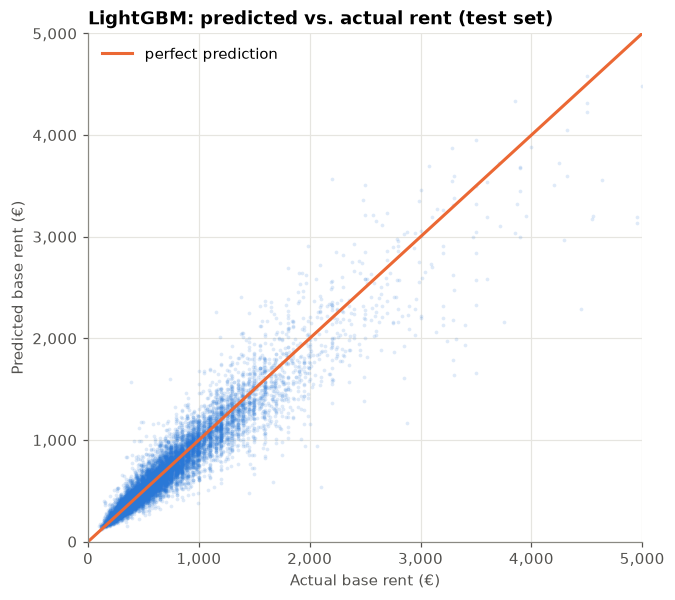

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 6))
idx = np.random.default_rng(0).choice(len(y_test), 15_000, replace=False)
ax.scatter(y_test.iloc[idx], pred[idx], s=6, alpha=0.15, color=BLUE, linewidths=0)
ax.plot([0, 5000], [0, 5000], color=ORANGE, lw=2, label="perfect prediction")
ax.set(title="LightGBM: predicted vs. actual rent (test set)", xlabel="Actual base rent (€)", ylabel="Predicted base rent (€)",
       xlim=(0, 5000), ylim=(0, 5000))
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=False)
plt.savefig("../images/predicted_vs_actual.png")
plt.show()

In [15]:
# Where is the model better or worse? Error per Bundesland
errors = pd.DataFrame({"state": X_test["regio1"].astype(str), "abs_error": np.abs(pred - y_test), "abs_pct_error": abs_pct_error})
per_state = errors.groupby("state").agg(test_listings=("abs_error", "size"), MAE_eur=("abs_error", "mean"),
                                        median_pct_error=("abs_pct_error", "median"))
per_state.sort_values("MAE_eur").round({"MAE_eur": 0, "median_pct_error": 3})

,test_listings,MAE_eur,median_pct_error
state,,,
Sachsen_Anhalt,3585,38.0,0.074
Thüringen,1625,39.0,0.068
Sachsen,10751,46.0,0.078
Mecklenburg_Vorpommern,1317,49.0,0.085
Brandenburg,1368,68.0,0.094
Bremen,566,75.0,0.092
Niedersachsen,3212,75.0,0.095
Nordrhein_Westfalen,12285,78.0,0.097
Saarland,281,81.0,0.099


## 8. What we learned

| Step | Test MAE | What it shows |
|---|---|---|
| Median baseline | €307 | The error to beat. R² is slightly below 0 – it explains nothing. |
| Linear Regression, 3 features | €175 | Size + Bundesland alone cut the error by **43%**. |
| Linear Regression, all features | €121 | City, year, condition and extras add a lot of information. |
| + log target | €114 | Lower MAE because percentage effects fit the log scale better. |
| Random Forest | €100 | Trees learn non-linear effects and interactions by themselves. |
| **LightGBM (log target)** | **€84.5** | **Best model: 72% lower error than the baseline**, R² 0.90. |

**Observations**
- **Cross-validation and test scores agree** (e.g. €84.6 vs. €84.5) and the CV spread is small (± €0.5). So the result is stable and not a lucky split.
- **Log target and R²:** for Linear Regression the log target lowered the MAE but also lowered R² (0.82 → 0.72). R² punishes *large* errors much more than MAE, and a log model predicts something closer to the *typical* (median) rent, so it tends to under-predict a few very expensive flats. For LightGBM, which can model those flats better, the log target wins on MAE with almost the same R². Since our metric is MAE, we choose **LightGBM (log target)**.
- **Typical error:** half of all predictions are within **±9.3%** of the real rent, and 81.5% are within ±20%.
- **Errors by region:** in euros, the error is largest in expensive markets (Hamburg €203, Berlin €185, Bayern €137) and smallest in the East (Sachsen-Anhalt €38). Part of that is simply higher prices. But even in **percent**, Hamburg (14.9%) and Berlin (12.8%) are the hardest. Rents there depend a lot on the exact neighbourhood, which our city-level feature can't see.

**Possible improvements** (not done, to keep the project focused): use the district (`regio3`) or postcode, tune LightGBM's settings with a proper search, and add newer data.

Next: `03_explainability.ipynb` – *why* does the model predict what it predicts?